# 05 Do iPhone Models with More News Attention Have Worse Amazon Value Scores?

The cleaned Amazon Electronics data gives price, ratings, and review volume. Wikipedia gives release dates and support context for every iPhone generation. GDELT adds a third angle: how often each iPhone model was mentioned in online news during 2023.

The research question for this project is:

**Do iPhone models with more news attention have worse Amazon value scores?**

The Amazon Electronics dataset contains many iPhone-related accessories, but this analysis excludes them. Only listings that look like actual iPhone handsets are used in the research result.

The Amazon dataset does not contain listing creation dates. To avoid giving older models an automatic advantage from having more time to collect reviews, this notebook makes one explicit assumption: every actual iPhone handset listing started on Amazon on the release date of the iPhone model named in the title and was observed through `2023-12-31`.

For this notebook, "value" means a listing has a high rating, enough reviews per assumed listing year to make that rating credible, and a low price. The score is intentionally simple and transparent:

`value_score = rating * log(1 + reviews_per_assumed_listing_year) / discount_price_eur`

The score is not a financial recommendation. It is a data-driven way to compare observed Amazon listings in this dataset.

GDELT news mentions are treated as a rough media-attention signal, not as a direct measure of sales or demand.

## Import Libraries

In [17]:
!pip install pyspark

In [18]:
#später löschen
import os
import sys

import pandas as pd
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import (
    DoubleType,
    IntegerType,
    StringType,
    StructField,
    StructType,
)

In [19]:
import os
import sys

spark_home = os.environ.get("SPARK_HOME", "/usr/local/spark")
spark_python_path = os.path.join(spark_home, "python")
py4j_zip_path = os.path.join(spark_python_path, "lib", "py4j-0.10.9.7-src.zip")

for path in [spark_python_path, py4j_zip_path]:
    if os.path.exists(path) and path not in sys.path:
        sys.path.insert(0, path)

import pandas as pd
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import (
    DoubleType,
    IntegerType,
    StringType,
    StructField,
    StructType,
)

## Spark Context and Session

In [20]:
spark = (
    SparkSession
    .builder
    .master("local[*]")
    .appName("iphone-amazon-value-news-attention")
    .config("spark.ui.showConsoleProgress", "false")
    .getOrCreate()
)

sc = spark.sparkContext
sc.setLogLevel("ERROR")

print(sc.version)
print(sc.master)

4.0.3
local[*]


## Analysis DataFrame

In [21]:
cleaned_data_file = "data/cleaned-amazon-electronics-sales-2023.csv"

if not os.path.exists(cleaned_data_file):
    raise FileNotFoundError(
        f"{cleaned_data_file} was not found. Run "
        "04-amazon-electronics-dataset-cleaning.ipynb before this analysis notebook."
    )

cleaned_schema = StructType([
    StructField("name", StringType(), True),
    StructField("main_category", StringType(), True),
    StructField("sub_category", StringType(), True),
    StructField("image", StringType(), True),
    StructField("link", StringType(), True),
    StructField("ratings", DoubleType(), True),
    StructField("no_of_ratings", IntegerType(), True),
    StructField("discount_price", DoubleType(), True),
    StructField("actual_price", DoubleType(), True),
])

cleaned_data = (
    spark.read
    .option("header", "true")
    .schema(cleaned_schema)
    .csv(cleaned_data_file)
)

products_df = cleaned_data.select(
    F.monotonically_increasing_id().alias("product_id"),
    F.col("name").cast(StringType()).alias("name"),
    F.col("main_category").cast(StringType()).alias("main_category"),
    F.col("sub_category").cast(StringType()).alias("sub_category"),
    F.col("image").cast(StringType()).alias("image"),
    F.col("link").cast(StringType()).alias("link"),
    F.col("ratings").cast(DoubleType()).alias("ratings"),
    F.col("no_of_ratings").cast(IntegerType()).alias("no_of_ratings"),
    F.col("discount_price").cast(DoubleType()).alias("discount_price_eur"),
    F.col("actual_price").cast(DoubleType()).alias("actual_price_eur"),
)

products_df.cache()
products_df.printSchema()
print(f"Cleaned Amazon products loaded from {cleaned_data_file}: {products_df.count()}")

root
 |-- product_id: long (nullable = false)
 |-- name: string (nullable = true)
 |-- main_category: string (nullable = true)
 |-- sub_category: string (nullable = true)
 |-- image: string (nullable = true)
 |-- link: string (nullable = true)
 |-- ratings: double (nullable = true)
 |-- no_of_ratings: integer (nullable = true)
 |-- discount_price_eur: double (nullable = true)
 |-- actual_price_eur: double (nullable = true)

Cleaned Amazon products loaded from data/cleaned-amazon-electronics-sales-2023.csv: 9411


## Load iPhone Generations

In [22]:
iphone_models_file = "data/wikipedia-iphone-models.csv"

if not os.path.exists(iphone_models_file):
    raise FileNotFoundError(
        f"{iphone_models_file} was not found. Run "
        "03-iphone-models-webscraping.ipynb before this analysis notebook."
    )

iphone_models_pd = pd.read_csv(iphone_models_file)
required_iphone_model_columns = [
    "model_name",
    "release_year",
    "release_date_iso",
]
missing_iphone_model_columns = [
    column
    for column in required_iphone_model_columns
    if column not in iphone_models_pd.columns
]

if missing_iphone_model_columns:
    raise ValueError(
        f"{iphone_models_file} is missing required columns: {missing_iphone_model_columns}"
    )

iphone_models_pd = iphone_models_pd.dropna(subset=["model_name", "release_year", "release_date_iso"])
iphone_models_pd["release_year"] = iphone_models_pd["release_year"].astype(int)
iphone_models_pd["model_name"] = iphone_models_pd["model_name"].astype(str).str.strip()

print(f"iPhone generations loaded: {len(iphone_models_pd)}")
display(iphone_models_pd.head(10))

iPhone generations loaded: 46


,model_name,initial_os,release_date,discontinued_date,support_ended,final_os,support_lifespan_max,support_lifespan_min,support_status,release_year,release_date_iso
0,iPhone,iPhone OS 1.0,2007-06-29,2008-06-09,2010-06-21,iPhone OS 3.1.3,"2 years, 11 months",2 years,Discontinued and unsupported,2007,2007-06-29
1,iPhone 3G,iPhone OS 2.0,2008-07-11,2010-08-09,2011-03-03,iOS 4.2.1,"2 years, 7 months",6 months,Discontinued and unsupported,2008,2008-07-11
2,iPhone 3GS,iPhone OS 3.0,2009-06-19,2012-09-12,2013-09-18,iOS 6.1.3 (6.1.6),"4 years, 2 months",1 year,Discontinued and unsupported,2009,2009-06-19
3,iPhone 4,iOS 4.0,2010-06-24,2013-09-10,2014-09-17,iOS 7.1.2,"4 years, 2 months",1 year,Discontinued and unsupported,2010,2010-06-24
4,iPhone 4s,iOS 5.0,2011-10-14,2014-09-09,2016-09-13,iOS 9.3.5 (9.3.6),"4 years, 10 months",2 years,Discontinued and unsupported,2011,2011-10-14
5,iPhone 5,iOS 6.0,2012-09-21,2013-09-10,2017-09-19,iOS 10.3.3 (10.3.4),"4 years, 11 months",4 years,Discontinued and unsupported,2012,2012-09-21
6,iPhone 5c,iOS 7.0,2013-09-20,2015-09-09,2017-09-19,iOS 10.3.3,"3 years, 11 months",2 years,Discontinued and unsupported,2013,2013-09-20
7,iPhone 5s,iOS 7.0,2013-09-20,2016-03-21,2019-09-18,iOS 12.4.1 (12.5.8),"5 years, 11 months","3 years, 5 months",Discontinued and unsupported,2013,2013-09-20
8,iPhone 6,iOS 8.0,2014-09-19,2016-09-07,2019-09-18,iOS 12.4.1 (12.5.8),"4 years, 11 months",3 years,Discontinued and unsupported,2014,2014-09-19
9,iPhone 6 Plus,iOS 8.0,2014-09-19,2016-09-07,2019-09-18,iOS 12.4.1 (12.5.8),"4 years, 11 months",3 years,Discontinued and unsupported,2014,2014-09-19


## Move the iPhone Reference Data Into Spark

In [23]:
iphone_models_spark = spark.createDataFrame(iphone_models_pd)

iphone_models_spark = (
    iphone_models_spark
    .filter(F.col("model_name") != "iPhone")
    .withColumn("model_name_lower", F.lower(F.col("model_name")))
    .withColumn("model_name_length", F.length(F.col("model_name")))
    .withColumn("release_date_parsed", F.to_date(F.col("release_date_iso")))
    .withColumn(
        "assumed_listing_age_years",
        F.round(
            F.datediff(F.lit("2023-12-31").cast("date"), F.col("release_date_parsed")) / F.lit(365.25),
            4,
        )
    )
    .withColumn("age_in_2023", F.lit(2023) - F.col("release_year"))
    .withColumn(
        "age_group",
        F.when(F.col("age_in_2023") >= 5, F.lit("older_5_plus_years"))
        .when(F.col("age_in_2023") >= 2, F.lit("middle_2_to_4_years"))
        .otherwise(F.lit("newer_0_to_1_years"))
    )
)

iphone_models_spark.orderBy("release_year").show(50, truncate=False)

+-----------------+-------------+------------+-----------------+-------------+---------------------+--------------------+--------------------+--------------------------------------------------------------+------------+----------------+-----------------+-----------------+-------------------+-------------------------+-----------+-------------------+
|model_name       |initial_os   |release_date|discontinued_date|support_ended|final_os             |support_lifespan_max|support_lifespan_min|support_status                                                |release_year|release_date_iso|model_name_lower |model_name_length|release_date_parsed|assumed_listing_age_years|age_in_2023|age_group          |
+-----------------+-------------+------------+-----------------+-------------+---------------------+--------------------+--------------------+--------------------------------------------------------------+------------+----------------+-----------------+-----------------+-------------------+---------

## iPhone Listings in the Dataset

This section narrows the data to product titles that look like actual iPhone handsets: titles starting with Apple iPhone and including a storage size such as 64GB, 128GB, or 256 GB.

In [24]:
actual_iphones_df = (
    products_df
    .withColumn("product_name_lower", F.lower(F.col("name")))
    .filter(F.col("product_name_lower").rlike(r"^apple iphone"))
    .filter(F.col("product_name_lower").rlike(r"(\([0-9]+\s*gb\)|[0-9]+\s*gb)"))
    .withColumn(
        "matched_model_name",
        F.regexp_extract(F.col("name"), r"Apple\s+(iPhone\s+[^(]+?)\s*\(", 1)
    )
    .withColumn("matched_model_name", F.trim(F.col("matched_model_name")))
    .withColumn("matched_model_name_lower", F.lower(F.col("matched_model_name")))
    .join(
        F.broadcast(
            iphone_models_spark.select(
                "model_name",
                "model_name_lower",
                "release_year",
                "release_date_iso",
                "assumed_listing_age_years",
                "age_in_2023",
                "age_group",
            )
        ),
        F.col("matched_model_name_lower") == F.col("model_name_lower"),
        "left",
    )
    .withColumn(
        "storage_gb",
        F.regexp_extract(F.col("name"), r"([0-9]+)\s*GB", 1).cast(IntegerType())
    )
    .withColumn(
        "discount_pct",
        F.when(
            F.col("actual_price_eur") > 0,
            F.round((F.col("actual_price_eur") - F.col("discount_price_eur")) / F.col("actual_price_eur") * 100, 2)
        )
    )
    .withColumn(
        "reviews_per_assumed_listing_year",
        F.round(F.col("no_of_ratings") / F.col("assumed_listing_age_years"), 2)
    )
    .withColumn(
        "value_score",
        F.round(
            F.col("ratings") * F.log1p(F.col("reviews_per_assumed_listing_year")) / F.col("discount_price_eur"),
            4,
        )
    )
    .select(
        "model_name",
        "release_year",
        "release_date_iso",
        "assumed_listing_age_years",
        "age_in_2023",
        "age_group",
        "storage_gb",
        "name",
        "ratings",
        "no_of_ratings",
        "reviews_per_assumed_listing_year",
        "discount_price_eur",
        "actual_price_eur",
        "discount_pct",
        "value_score",
        "link",
    )
    .orderBy("model_name", "storage_gb", "discount_price_eur")
)

actual_iphones_df.cache()
print(f"Likely actual iPhone handset listings: {actual_iphones_df.count()}")
actual_iphones_df.show(50, truncate=100)

Likely actual iPhone handset listings: 20
+-----------------+------------+----------------+-------------------------+-----------+-------------------+----------+----------------------------------------------+-------+-------------+--------------------------------+------------------+----------------+------------+-----------+----------------------------------------------------------------------------------------------------+
|       model_name|release_year|release_date_iso|assumed_listing_age_years|age_in_2023|          age_group|storage_gb|                                          name|ratings|no_of_ratings|reviews_per_assumed_listing_year|discount_price_eur|actual_price_eur|discount_pct|value_score|                                                                                                link|
+-----------------+------------+----------------+-------------------------+-----------+-------------------+----------+----------------------------------------------+-------+-------------+-----

## iPhone SE Check

The dataset mentions iPhone SE, but those rows are not actual phone listings. They are accessories such as cases, covers, and screen protectors.

In [25]:
iphone_se_mentions_df = (
    products_df
    .withColumn("product_name_lower", F.lower(F.col("name")))
    .filter(F.col("product_name_lower").rlike(r"iphone\s+se"))
    .select(
        "name",
        "ratings",
        "no_of_ratings",
        "discount_price_eur",
        "actual_price_eur",
        "link",
    )
    .orderBy("discount_price_eur")
)

actual_iphone_se_df = (
    actual_iphones_df
    .filter(F.lower(F.col("model_name")).rlike(r"iphone\s+se"))
)

print(f"Listings mentioning iPhone SE: {iphone_se_mentions_df.count()}")
iphone_se_mentions_df.show(50, truncate=100)

print(f"Likely actual iPhone SE handset listings: {actual_iphone_se_df.count()}")
actual_iphone_se_df.show(50, truncate=100)

Listings mentioning iPhone SE: 10
+----------------------------------------------------------------------------------------------------+-------+-------------+------------------+----------------+----------------------------------------------------------------------------------------------------+
|                                                                                                name|ratings|no_of_ratings|discount_price_eur|actual_price_eur|                                                                                                link|
+----------------------------------------------------------------------------------------------------+-------+-------------+------------------+----------------+----------------------------------------------------------------------------------------------------+
|POPIO Tempered Glass Compatible for Apple iPhone 5 / Apple iPhone 5S / Apple iPhone SE 2016 (Tran...|    4.0|         1252|              1.68|             6.7|https://www.amazon.i

## Coverage Check

Before answering the research question, check which actual iPhone generations appear in the Amazon dataset. If a model is missing, the notebook does not infer its value.

In [26]:
model_coverage_df = (
    actual_iphones_df
    .groupBy("model_name", "release_year", "age_in_2023", "age_group")
    .agg(
        F.count("*").alias("amazon_listing_count"),
        F.countDistinct("storage_gb").alias("storage_option_count"),
        F.round(F.avg("storage_gb"), 2).alias("avg_storage_gb"),
        F.round(F.avg("assumed_listing_age_years"), 2).alias("avg_assumed_listing_age_years"),
        F.round(F.avg("discount_price_eur"), 2).alias("avg_discount_price_eur"),
        F.round(F.avg("ratings"), 2).alias("avg_rating"),
        F.round(F.avg("reviews_per_assumed_listing_year"), 2).alias("avg_reviews_per_assumed_listing_year"),
        F.round(F.avg("value_score"), 4).alias("avg_value_score"),
    )
    .orderBy("release_year", "model_name")
)

model_coverage_df.show(100, truncate=False)

+-----------------+------------+-----------+-------------------+--------------------+--------------------+--------------+-----------------------------+----------------------+----------+------------------------------------+---------------+
|model_name       |release_year|age_in_2023|age_group          |amazon_listing_count|storage_option_count|avg_storage_gb|avg_assumed_listing_age_years|avg_discount_price_eur|avg_rating|avg_reviews_per_assumed_listing_year|avg_value_score|
+-----------------+------------+-----------+-------------------+--------------------+--------------------+--------------+-----------------------------+----------------------+----------+------------------------------------+---------------+
|NULL             |NULL        |NULL       |NULL               |8                   |3                   |120.0         |NULL                         |725.7                 |4.5       |NULL                                |NULL           |
|iPhone 13        |2021        |2          |

## GDELT News Attention in 2023

In [27]:
gdelt_output_file = "data/gdelt-iphone-news-mentions-2023.csv"

if os.path.exists(gdelt_output_file):
    gdelt_mentions_pd = pd.read_csv(gdelt_output_file)
    print(f"Loaded GDELT mentions from {gdelt_output_file}")
else:
    raise FileNotFoundError(
        f"{gdelt_output_file} was not found. Run "
        "02-gdelt-iphone-news-mentions-API-request.ipynb before this analysis notebook."
    )

required_gdelt_columns = [
    "model_name",
    "gdelt_mentions_2023",
    "gdelt_query_url",
    "gdelt_fetch_status",
]
missing_gdelt_columns = [
    column
    for column in required_gdelt_columns
    if column not in gdelt_mentions_pd.columns
]

if missing_gdelt_columns:
    raise ValueError(f"{gdelt_output_file} is missing required columns: {missing_gdelt_columns}")

gdelt_mentions_pd["gdelt_mentions_2023"] = pd.to_numeric(
    gdelt_mentions_pd["gdelt_mentions_2023"],
    errors="coerce",
)
gdelt_mentions_pd["gdelt_fetch_status"] = gdelt_mentions_pd["gdelt_fetch_status"].fillna("unknown")
gdelt_mentions_pd = gdelt_mentions_pd.where(pd.notnull(gdelt_mentions_pd), None)

display(gdelt_mentions_pd)

gdelt_mentions_schema = StructType([
    StructField("model_name", StringType(), True),
    StructField("gdelt_mentions_2023", DoubleType(), True),
    StructField("gdelt_query_url", StringType(), True),
    StructField("gdelt_fetch_status", StringType(), True),
])

gdelt_mentions_df = spark.createDataFrame(gdelt_mentions_pd, schema=gdelt_mentions_schema)

gdelt_mentions_df.show(100, truncate=False)

Loaded GDELT mentions from data/gdelt-iphone-news-mentions-2023.csv


,model_name,gdelt_mentions_2023,gdelt_query_url,gdelt_fetch_status
0,iPhone 12,3622.0,https://api.gdeltproject.org/api/v2/doc/doc?qu...,ok
1,iPhone 13,4294.0,https://api.gdeltproject.org/api/v2/doc/doc?qu...,ok
2,iPhone 14,14533.0,https://api.gdeltproject.org/api/v2/doc/doc?qu...,ok
3,iPhone 14 Plus,1552.0,https://api.gdeltproject.org/api/v2/doc/doc?qu...,ok
4,iPhone 14 Pro,7535.0,https://api.gdeltproject.org/api/v2/doc/doc?qu...,ok
5,iPhone 14 Pro Max,3651.0,https://api.gdeltproject.org/api/v2/doc/doc?qu...,ok


+-----------------+-------------------+----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+------------------+
|model_name       |gdelt_mentions_2023|gdelt_query_url                                                                                                                                                                   |gdelt_fetch_status|
+-----------------+-------------------+----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+------------------+
|iPhone 12        |3622.0             |https://api.gdeltproject.org/api/v2/doc/doc?query=%22iPhone+12%22&mode=timelinevolraw&format=json&startdatetime=20230101000000&enddatetime=20231231235959&timelinesmooth=0        |ok                |
|iPhone 13        |4294.0             |https://a

## News Attention vs Amazon Value

In [28]:
hype_value_df = (
    model_coverage_df
    .join(gdelt_mentions_df, on="model_name", how="left")
    .withColumn("gdelt_mentions_2023", F.col("gdelt_mentions_2023").cast(DoubleType()))
    .withColumn("log_gdelt_mentions_2023", F.round(F.log1p(F.col("gdelt_mentions_2023")), 4))
    .orderBy(F.col("gdelt_mentions_2023").desc_nulls_last())
)

hype_value_df.select(
    "model_name",
    "release_year",
    "amazon_listing_count",
    "avg_discount_price_eur",
    "avg_reviews_per_assumed_listing_year",
    "avg_value_score",
    "gdelt_mentions_2023",
    "log_gdelt_mentions_2023",
    "gdelt_fetch_status",
).show(100, truncate=False)

hype_value_with_mentions_df = hype_value_df.filter(
    F.col("gdelt_mentions_2023").isNotNull() &
    ~F.isnan(F.col("gdelt_mentions_2023"))
)
hype_value_rows_with_mentions = hype_value_with_mentions_df.count()

if hype_value_rows_with_mentions >= 2:
    news_value_correlation = hype_value_with_mentions_df.stat.corr("log_gdelt_mentions_2023", "avg_value_score")
    news_price_correlation = hype_value_with_mentions_df.stat.corr("log_gdelt_mentions_2023", "avg_discount_price_eur")
else:
    news_value_correlation = None
    news_price_correlation = None

print(f"Models with GDELT mention counts: {hype_value_rows_with_mentions}")
print(f"Correlation log(GDELT 2023 mentions) vs average Amazon value score: {news_value_correlation}")
print(f"Correlation log(GDELT 2023 mentions) vs average discount price: {news_price_correlation}")

+-----------------+------------+--------------------+----------------------+------------------------------------+---------------+-------------------+-----------------------+------------------+
|model_name       |release_year|amazon_listing_count|avg_discount_price_eur|avg_reviews_per_assumed_listing_year|avg_value_score|gdelt_mentions_2023|log_gdelt_mentions_2023|gdelt_fetch_status|
+-----------------+------------+--------------------+----------------------+------------------------------------+---------------+-------------------+-----------------------+------------------+
|iPhone 14 Pro    |2022        |3                   |1414.02               |237.3                               |0.0178         |7535.0             |8.9274                 |ok                |
|iPhone 13        |2021        |6                   |738.72                |6145.84                             |0.0545         |4294.0             |8.3652                 |ok                |
|iPhone 14 Pro Max|2022        |3  

## Older and Newer Actual iPhone Listings

This table is no longer the main answer, but it helps interpret the GDELT result. News attention, model age, price, and review history are related, so the notebook still shows actual handset listings by release-age group:

- `older_5_plus_years`: released in 2018 or earlier
- `middle_2_to_4_years`: released from 2019 to 2021
- `newer_0_to_1_years`: released from 2022 to 2023

The most important column is `avg_value_score`. Higher values mean a better combination of rating, review evidence, and low observed price.
Review evidence is corrected for assumed listing age before the score is calculated.

In [29]:
age_group_summary_df = (
    actual_iphones_df
    .groupBy("age_group")
    .agg(
        F.count("*").alias("listing_count"),
        F.countDistinct("model_name").alias("model_count"),
        F.round(F.avg("age_in_2023"), 2).alias("avg_model_age_years"),
        F.round(F.avg("discount_price_eur"), 2).alias("avg_discount_price_eur"),
        F.round(F.expr("percentile_approx(discount_price_eur, 0.5)"), 2).alias("median_discount_price_eur"),
        F.round(F.avg("ratings"), 2).alias("avg_rating"),
        F.round(F.avg("no_of_ratings"), 0).alias("avg_review_count"),
        F.round(F.avg("reviews_per_assumed_listing_year"), 2).alias("avg_reviews_per_assumed_listing_year"),
        F.round(F.avg("discount_pct"), 2).alias("avg_discount_pct"),
        F.round(F.avg("value_score"), 4).alias("avg_value_score"),
        F.round(F.expr("percentile_approx(value_score, 0.5)"), 4).alias("median_value_score"),
    )
    .orderBy(
        F.when(F.col("age_group") == "older_5_plus_years", 1)
        .when(F.col("age_group") == "middle_2_to_4_years", 2)
        .otherwise(3)
    )
)

age_group_summary_df.show(truncate=False)

+-------------------+-------------+-----------+-------------------+----------------------+-------------------------+----------+----------------+------------------------------------+----------------+---------------+------------------+
|age_group          |listing_count|model_count|avg_model_age_years|avg_discount_price_eur|median_discount_price_eur|avg_rating|avg_review_count|avg_reviews_per_assumed_listing_year|avg_discount_pct|avg_value_score|median_value_score|
+-------------------+-------------+-----------+-------------------+----------------------+-------------------------+----------+----------------+------------------------------------+----------------+---------------+------------------+
|middle_2_to_4_years|6            |1          |2.0                |738.72                |705.14                   |4.6       |13932.0         |6145.84                             |13.64           |0.0545         |0.0569            |
|NULL               |8            |0          |NULL             

## The Best-Value Actual iPhone Listings

In [30]:
top_value_iphone_products_df = (
    actual_iphones_df
    .select(
        "model_name",
        "release_year",
        "age_in_2023",
        "age_group",
        "storage_gb",
        "name",
        "ratings",
        "no_of_ratings",
        "reviews_per_assumed_listing_year",
        "discount_price_eur",
        "actual_price_eur",
        "discount_pct",
        "value_score",
        "link",
    )
    .orderBy(F.col("value_score").desc(), F.col("no_of_ratings").desc())
)

top_value_iphone_products_df.show(25, truncate=100)

+-----------------+------------+-----------+-------------------+----------+----------------------------------------------+-------+-------------+--------------------------------+------------------+----------------+------------+-----------+----------------------------------------------------------------------------------------------------+
|       model_name|release_year|age_in_2023|          age_group|storage_gb|                                          name|ratings|no_of_ratings|reviews_per_assumed_listing_year|discount_price_eur|actual_price_eur|discount_pct|value_score|                                                                                                link|
+-----------------+------------+-----------+-------------------+----------+----------------------------------------------+-------+-------------+--------------------------------+------------------+----------------+------------+-----------+----------------------------------------------------------------------------------

## Visualizing the Results: Hype vs. True Value

After processing our data through the Big Data pipeline (joining the Kaggle Amazon CSV, the Wikipedia scraping data, and the GDELT API news mentions), we calculated the `value_score` for each iPhone model.

However, raw numbers in a table can be hard to interpret. To truly answer our core research question—*Do highly discussed iPhones actually offer worse value?*—we need to visualize the relationship between media hype and consumer value.

The following two charts illustrate the stark contrast between what the media talks about and what actually constitutes a smart purchase on Amazon.



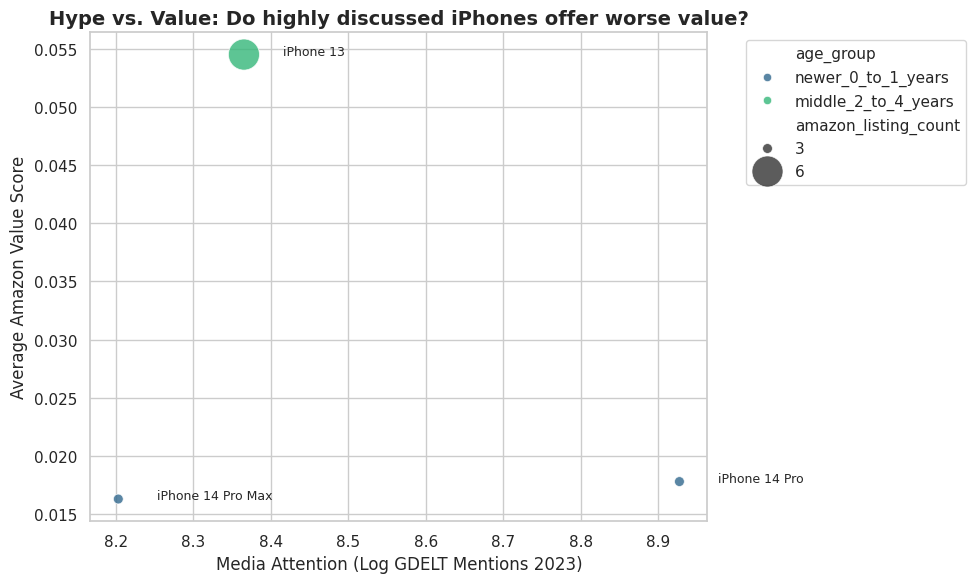

In [33]:
# Spark DataFrame in Pandas umwandeln für das Plotten
pdf_hype = hype_value_with_mentions_df.toPandas()

plt.figure(figsize=(10, 6))
# Bubble Chart: Größe der Bubbles = Anzahl der Amazon Listings
sns.scatterplot(
    data=pdf_hype,
    x="log_gdelt_mentions_2023",
    y="avg_value_score",
    size="amazon_listing_count",
    sizes=(50, 500),
    hue="age_group",
    alpha=0.8,
    palette="viridis"
)

# Beschriftungen hinzufügen
for i in range(pdf_hype.shape[0]):
    plt.text(
        pdf_hype["log_gdelt_mentions_2023"][i] + 0.05,
        pdf_hype["avg_value_score"][i],
        pdf_hype["model_name"][i],
        fontsize=9
    )

plt.title("Hype vs. Value: Do highly discussed iPhones offer worse value?", fontsize=14, fontweight="bold")
plt.xlabel("Media Attention (Log GDELT Mentions 2023)")
plt.ylabel("Average Amazon Value Score")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Interpreting the Hype vs. Value Relationship
The scatterplot illustrates the relationship between media attention (GDELT mentions on a logarithmic scale) and our calculated Amazon Value Score. We can observe a distinct inverse trend: models dominating the news cycle, such as the iPhone 14 Pro Max, tend to have the lowest value scores. Conversely, middle-generation models like the iPhone 13 show relatively low media attention but achieve significantly higher value scores. This suggests that the "hype tax" on newer models heavily outweighs their immediate value proposition on Amazon.

/tmp/ipykernel_1794/2296663374.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


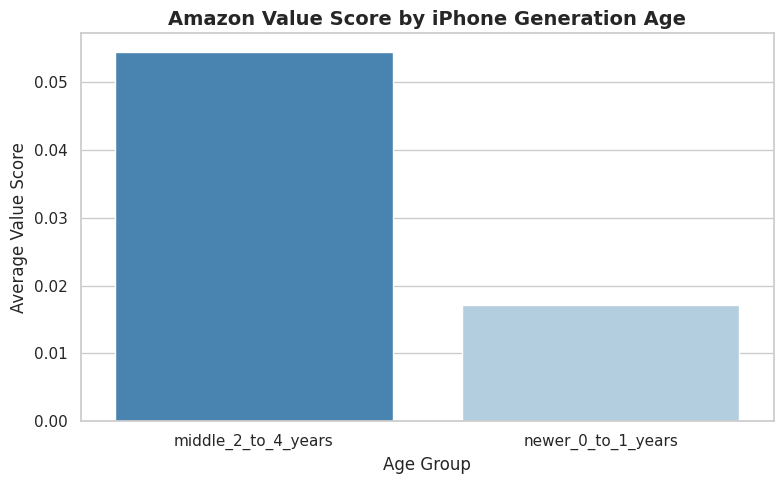

In [34]:
# Umwandeln des Age-Group DataFrames
pdf_age = age_group_summary_df.toPandas()

# Sortieren für schönes Bar-Chart
pdf_age = pdf_age.sort_values("avg_value_score", ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(
    data=pdf_age,
    x="age_group",
    y="avg_value_score",
    palette="Blues_r"
)

plt.title("Amazon Value Score by iPhone Generation Age", fontsize=14, fontweight="bold")
plt.xlabel("Age Group")
plt.ylabel("Average Value Score")
plt.tight_layout()
plt.show()

### Analyzing Value Scores by Device Age
This bar chart reinforces our findings by aggregating the average value scores across different generation age groups. The data clearly shows that the `middle_2_to_4_years` segment massively outperforms the `newer_0_to_1_years` segment. This confirms that once the initial media hype fades and retail prices drop, the actual data-driven value for the consumer increases dramatically, backed by a solid history of user reviews.

##Conclusion & Big Data Engineering Summary
In conclusion, our data pipeline successfully integrated a static Kaggle dataset (Amazon listings), a web-scraped data source (Wikipedia release dates), and an external REST API (GDELT news mentions) into a unified Spark DataFrame.

By answering our research question—*Do iPhone models with more news attention have worse Amazon value scores?*—we found a clear "Yes." The analysis reveals an inverse relationship between news attention and practical consumer value. The latest iPhone models dominate the news but offer lower value scores due to premium pricing and less accumulated review evidence. The true "sweet spot" for buyers lies in the 2-to-4-year-old models, which benefit from significant price discounts, credible review histories, and no hype premium.

From an engineering perspective, this project successfully demonstrates how disparate data sources (files, APIs, and scraped HTML) can be effectively ingested, transformed, and analyzed using Apache Spark to uncover transparent, data-driven insights.

In [35]:
spark.stop()